# Generating a dataset

I have three methods for generating datasets that satisfy the manifold hypothesis.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from pyspoc import Calculator, Config

Starting JVM with java class C:\Users\Lenovo\Desktop\Master\Master thesis\Notebooks\py-spoc\pyspoc/lib/jidt/infodynamics.jar.
Jpype JVM not available: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


### Gaussian manifolds

In [8]:
class Manifold_gaussian:
    """
    Generates an N-point Gaussian manifold of dimension manifold_dim
    (i.e. a Gaussian blob in R^manifold_dim with given mean & variance),
    then randomly embeds it into R^embed_dim via a Gaussian projection.
    """

    def __init__(
        self,
        n_samples: int,
        manifold_dim: int,
        embed_dim: int,
        mean: float = 0.0,
        variance: float = 1.0,
        random_state: int | None = None,
    ):

        """
        Parameters
        ----------
        n_samples : int
            Number of points to draw from the Gaussian in the low‐dim manifold.
        manifold_dim : int
            Intrinsic dimension of the Gaussian manifold.
        embed_dim : int
            Target ambient dimension to embed into.
        mean : float or array‐like of length manifold_dim
            Center of the Gaussian in the manifold space.
        variance : float
            Variance of each coordinate in the manifold (isotropic).
        random_state : int or None
            Seed for reproducibility.
        """
        self.n_samples = n_samples
        self.manifold_dim = manifold_dim
        self.embed_dim = embed_dim
        self.mean = (
            np.full(manifold_dim, mean)
            if np.isscalar(mean)
            else np.asarray(mean, dtype=float)
        )

        if self.mean.shape != (manifold_dim,):
            raise ValueError("`mean` must be scalar or length-manifold_dim array")
        if variance <= 0:
            raise ValueError("`variance` must be positive")
        self.variance = variance
        self.rng = np.random.default_rng(random_state)

        # pre-sample the random embedding matrix
        # scale by 1/√manifold_dim so each embedded coord has ~unit variance
        self._W = self.rng.normal(
            loc=0.0,
            scale=1.0 / np.sqrt(manifold_dim),
            size=(manifold_dim, embed_dim),
        )

    def generate(self) -> np.ndarray:
        """
        Returns
        -------
        X_embedded : ndarray, shape (n_samples, embed_dim)
            Points sampled from the Gaussian manifold and then embedded into
            R^embed_dim.
        """

        # Sample the low‐dim Gaussian cloud
        X_low = self.rng.normal(
            loc=0.0,
            scale=np.sqrt(self.variance),
            size=(self.n_samples, self.manifold_dim),
        )
        # Shift by the mean
        X_low += self.mean.reshape(1, -1)
        self.Z = X_low

        # Embed into high dimension
        X_embedded = X_low @ self._W
        return X_embedded




### Geometric manifolds

This has two parts. The manifold generating class, and the domain from which the parametrisation of the manifold will take values. Just use the given domains. The class is this long mainly because of the plotting utilities.

In [9]:
class Manifold:
    # Built-in manifold generators: map domain points (n, d_domain) -> ambient points (n, D)
    Manifold_dictionary = {
        "unit interval": {"fn": lambda domain: domain.reshape(-1, 1), "domain_dim": 1},
        "unit circle":   {"fn": lambda domain: np.vstack((
                                np.cos(domain[:, 0]),
                                np.sin(domain[:, 0])
                              )).T, "domain_dim": 1},
        # Disc uses specialized sampling to ensure uniform area density
        "disc":          {"fn": staticmethod(
                                lambda domain, U: np.vstack((
                                    U[:, 0] * np.cos(U[:, 1]),
                                    U[:, 0] * np.sin(U[:, 1])
                                )).T
                            ), "domain_dim": 2},
        "figure eight": {"fn": lambda domain: np.vstack((
                                    np.cos(domain[:,0]),
                                    np.sin(domain[:,0]) * np.cos(domain[:,0])
                                )).T,
                                "domain_dim": 1},
        "unit sphere":   {"fn": staticmethod(
                                lambda domain: np.vstack((
                                    np.sin(domain[:, 1]) * np.cos(domain[:, 0]),
                                    np.sin(domain[:, 1]) * np.sin(domain[:, 0]),
                                    np.cos(domain[:, 1])
                                )).T

                            ), "domain_dim": 2},
        "torus":         {"fn": staticmethod(
                                lambda domain: np.vstack((
                                    (1 + 0.2 * np.cos(domain[:, 1])) * np.cos(domain[:, 0]),
                                    (1 + 0.2 * np.cos(domain[:, 1])) * np.sin(domain[:, 0]),
                                    0.2 * np.sin(domain[:, 1])
                                )).T
                            ), "domain_dim": 2},
        "cylinder":      {"fn": staticmethod(
                                lambda domain: np.vstack((
                                    np.cos(domain[:, 0]),
                                    np.sin(domain[:, 0]),
                                    domain[:, 1]
                                )).T
                            ), "domain_dim": 2},
        "swiss roll":    {"fn": staticmethod(
                                lambda domain: np.vstack((
                                    domain[:, 0] * np.cos(domain[:, 0]),
                                    domain[:, 1],
                                    domain[:, 0] * np.sin(domain[:, 0])
                                )).T
                            ), "domain_dim": 2},
        "s curve":       {"fn": staticmethod(
                                lambda domain: np.vstack((
                                    np.sin(domain[:, 0]),
                                    domain[:, 1],
                                    np.sign(domain[:, 0]) * (1 - np.cos(domain[:, 0]))
                                )).T
                            ), "domain_dim": 2},
    }


    def __init__(self, name, domain, n_samples, noise=0.0):
        """
        name (str): one of Manifold_dictionary keys.
        domain (array-like): shape (d,2) specifying [min, max] for each domain dim.
        n_samples (int): number of samples.
        noise (float): std dev of Gaussian noise to add.
        """
        self.name = name
        self.noise = noise
        self.n_samples = n_samples

        if name not in Manifold.Manifold_dictionary:
            raise ValueError(f"Unknown manifold '{name}'. Available: {list(Manifold.Manifold_dictionary)}")
        entry = Manifold.Manifold_dictionary[name]
        self.fn = entry["fn"]
        expected_dim = entry["domain_dim"]

        domain = np.asarray(domain, dtype=float)
        if domain.ndim != 2 or domain.shape[1] != 2:
            raise TypeError("Domain must be array-like of shape (d,2)")
        d = domain.shape[0]
        if d != expected_dim:
            raise ValueError(f"Manifold '{name}' expects domain dimension {expected_dim}, got {d}")
        self.domain = domain


    def generate(self):
        """
        Sample the manifold with correct area/volume weighting, add noise, return (n_samples, D).
        Saves the sampled domain in self.U for coloring.
        """
        lows = self.domain[:, 0]
        highs = self.domain[:, 1]
        d = len(lows)

        if self.name == "disc":
            # Uniform area sampling: radial ~ sqrt(uniform), theta ~ uniform
            r = np.sqrt(
                np.random.rand(self.n_samples) * (highs[0]**2 - lows[0]**2) + lows[0]**2
            )
            theta = np.random.rand(self.n_samples) * (highs[1] - lows[1]) + lows[1]
            U = np.vstack((r, theta)).T
            X = self.fn(self.domain, U)
        else:
            # Uniform sampling over domain rectangle
            U = np.random.rand(self.n_samples, d) * (highs - lows)[None, :] + lows[None, :]
            X = self.fn(U)

        self.U = U
        self.ambient_dim = X.shape[1]


        if self.noise > 0:
            E = np.random.randn(*X.shape)
            self.data = X + self.noise * E
        else:
            self.data = X
        return self.data

    def plot(self):
        """
        Scatter-plot the last generated data if ambient_dim <= 3.
        Colors each point by its first domain coordinate; for 1D shows just points along domain.
        """
        if not hasattr(self, 'data'):
            raise RuntimeError("No data generated yet; call generate() first.")
        X = self.data
        U = getattr(self, 'U', None)
        n, D = X.shape
        if D > 3:
            raise ValueError("Cannot plot data with ambient dimension > 3.")

        # Color array
        c = U[:, 0] if U is not None else None


        if D == 1:
            plt.figure()
            plt.scatter(X[:, 0], np.zeros(n), c=c, cmap='viridis', marker='o')
            plt.ylim(-0.1, 0.1)
            plt.yticks([])
            plt.xlabel('Domain')
            plt.title(f"{self.name} (1D)")
            plt.show()

        elif D == 2:
            plt.figure()
            plt.scatter(X[:, 0], X[:, 1], c=c, cmap='viridis', alpha=0.7)
            plt.xlabel('Coord 0'); plt.ylabel('Coord 1')
            plt.title(f"{self.name} (2D)")
            plt.axis('equal'); plt.show()

        else:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=c, cmap='viridis', alpha=0.7)
            ax.set_xlabel('Coord 0'); ax.set_ylabel('Coord 1'); ax.set_zlabel('Coord 2')
            ax.set_title(f"{self.name} (3D)")


            # Equal aspect for 3D
            ranges = np.ptp(X, axis=0)
            max_range = ranges.max()
            centers = X.min(axis=0) + ranges/2
            ax.set_xlim(centers[0]-max_range/2, centers[0]+max_range/2)
            ax.set_ylim(centers[1]-max_range/2, centers[1]+max_range/2)
            ax.set_zlim(centers[2]-max_range/2, centers[2]+max_range/2)
            plt.show()

In [10]:
# Define sampling domains for each built-in manifolds
manifold_domains = {
    "unit interval":  np.array([[0.0, 1.0]]),
    "unit circle":    np.array([[0.0, 2*np.pi]]),
    "disc":           np.array([[0.0, 1.0],       [0.0, 2*np.pi]]),
    "figure eight":   np.array([[0.0, 2*np.pi]]),               # Gerono's lemniscate
    "unit sphere":    np.array([[0.0, 2*np.pi], [0.0, np.pi]]),
    "torus":          np.array([[0.0, 2*np.pi], [0.0, 2*np.pi]]),
    "cylinder":       np.array([[0.0, 2*np.pi], [0.0, 1.0]]),
    "swiss roll":     np.array([[1.5*np.pi, 4.5*np.pi], [0.0, 21.0]]),
    "s curve":        np.array([[-1.5*np.pi, 1.5*np.pi],[0.0, 2.0]])
}

### Embedding function

This is just for the geometric method, the Gaussian one already implements an embedding process in the class.

In [11]:
def random_embed(X, dim=50, random_state=None):
    """
    Embed the N×2 array X into R^dim by a fresh Gaussian random projection.
    """
    rs = np.random.default_rng(random_state)
    D = X.shape[1]
    # scale by 1/sqrt(D) so each output coordinate has unit variance
    W = rs.normal(size=(D, dim)) / np.sqrt(D)
    return X @ W

### Latent Metric Model

You will need to install the Python package from https://github.com/pablo-saborido/LaMM_Gen.git. Alternatively, go to the repo, the LaMM_Gen folder, and then the model.py file. Copy everything into the notebook if you do not want to install the package.

In [12]:
from LaMM_Gen.model import LMM

### Example of generating a dataset

If you choose the Gaussian manifold method:

In [18]:
N = 5000
p = 50
MG = Manifold_gaussian(
                n_samples    = N,
                manifold_dim = 3,
                embed_dim    = p,
                mean         = 0.0,
                variance     = 1.0,
                random_state = 42
            )
Y     = MG.generate()     

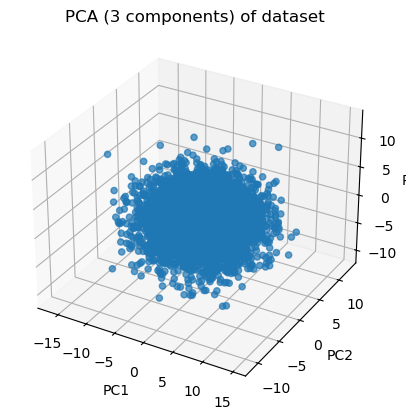

In [19]:
# plotting a 3d representation (through PCA) of the high-dimensional space
pca = PCA(n_components=3)
Y_pca = pca.fit_transform(Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], Y_pca[:, 2], alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA (3 components) of dataset")
plt.show()

If you choose the geometric manifold option (pick the manifold shape that you prefer by changing the variable 'name'):

In [31]:
print(f'Available values for name: {list(Manifold.Manifold_dictionary.keys())}')

Available values for name: ['unit interval', 'unit circle', 'disc', 'figure eight', 'unit sphere', 'torus', 'cylinder', 'swiss roll', 's curve']


In [26]:
name = 'figure eight'
N = 5000
p = 50
dom  = manifold_domains[name] # pick the domain of the parametrisation (do not change)
M = Manifold(name, dom, n_samples=N, noise=0.01)
X = M.generate()   # This is the low-dimensional manifold, not the high-dimensional dataset
Y = random_embed(X, dim=p, random_state=42) # this is the high-dimensional dataset

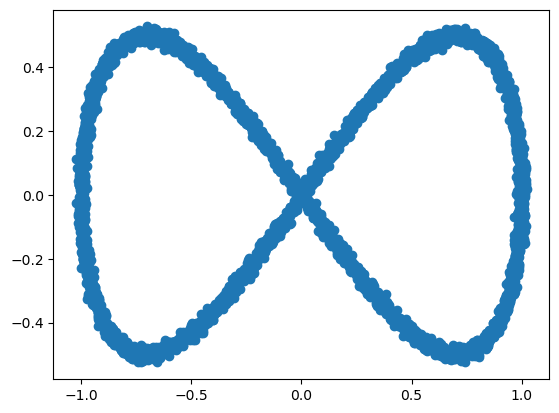

In [27]:
# plotting the low-dimensional manifold
plt.scatter(X[:,0],X[:,1])
plt.show()

If you choose the LMM (pick a different Z for different shapes of the latent dimension):

In [33]:
print(f'Available values for name: {list(LMM.Latent_dictionary)}')

Available values for name: ['unit interval', 'unit circle', 'figure eight', 'unit sphere', 'ball', 'cylinder', 'swiss roll', 's curve', 's surface', 'torus']


In [46]:
N = 5000 # if you want more samples, it might take a long time, I would not recomment going over 5000
p = 50
model = LMM(Z='torus', covariance_kernel='RBF', sigma=0.01, n_latent=N, latent_params=None)
Y = model.generate(p)

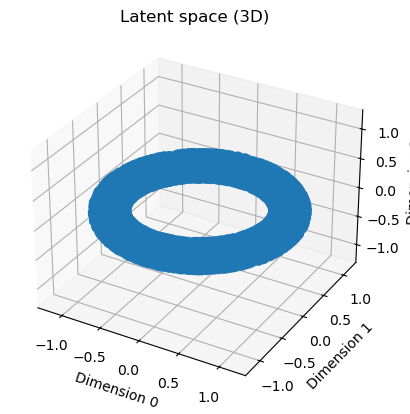

In [47]:
# plotting the latent space
model.plot_latent()

# Using the reduced statistics

The files where the reduced statistics are import from other files in the same folder. At the moment, the way of allowing this without errors is changing the working directory of the notebook to the folder with the reduced statistics. So, provided you have cloned the repo, change the beginning of the next line accordingly.

In [48]:
%cd py-spoc/working_analyses/mastersResearch_Jun_Sept2025/dimRed_P/Reducedstatistics 

[WinError 3] El sistema no puede encontrar la ruta especificada: 'py-spoc/working_analyses/mastersResearch_Jun_Sept2025/dimRed_P/Reducedstatistics'
C:\Users\Lenovo\Desktop\Master\Master thesis\Notebooks\py-spoc\working_analyses\mastersResearch_Jun_Sept2025\dimRed_P\Reducedstatistics


A dimensionality reduction method has to be chosen for the reduciton process. Isomap has given the best results for my purposes, so maybe use that one.

In [49]:
# Building the config
method = 'Isomap'
my_config_dict = {'ReducedStatistics': {
    'All_coranking_metrics.py':
     {'All_coranking_metrics':{
         'schemes':{
             'scheme_1': {'method': method}
         }
     }}
}}

cfg = Config.from_dict("auto_cfg", my_config_dict)

Registering configuration dictionary object.
Building internal configuration.
  ✔ Module All_coranking_metrics.py already loaded.
    ✔ ReducedStatistic All_coranking_metrics scheme 'scheme_1' added successfully.


In [50]:
# Computing the outputs from out reduced statistics
calc = Calculator(Y)
calc.compute(cfg)
df = calc.results.copy()
names = ['Distance_similarity','Continuity','Trustworthiness',
        'Q_NN','LCMC','Q_local','Q_global']
df.columns = names # give names to each entry in the output, I have already checked that this is the order

Normalising the dataset using StandardScaler 



Processing [None: All_coranking_metrics.py.All_coranking_metrics.scheme_1]: 100%|███████| 1/1 [10:21<00:00, 621.43s/it]


Calculation complete. Time taken: 621.4295s


As you can see, with N=5000 it took 10 mins.

In [51]:
df

,Distance_similarity,Continuity,Trustworthiness,Q_NN,LCMC,Q_local,Q_global
0,0.872866,0.978856,0.97921,0.888876,0.888876,0.71365,0.921544


Values near 1 mean that the dataset is very 'manifoldy', while values near 0 mean that it is not.